# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [118]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [119]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [120]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [72]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [73]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [74]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

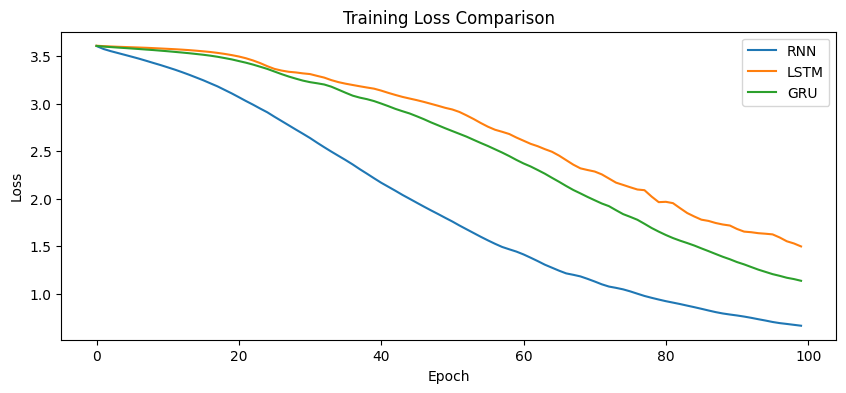

In [75]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [76]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [77]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models transforming generate meaningful sentences
LSTM: deep learning models transforming generate meaningful sentences
GRU : deep learning is transforming artificial intelligence intelligence


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

## ✅ Conclusion

#. Vanilla RNN learns short patterns but struggles with memory

#. LSTM captures long-range grammar dependencies better

#. GRU gives similar performance with fewer gates and faster training

#. This notebook helps students understand sequence modeling mathematically and practically



##

## 🧠 We use a small built-in sample corpus so students can run this quickly. You can later replace it with:

#. Shakespeare text

#. song lyrics

#. chatbot data

#. story paragraphs

#. custom PDF extracted text

## Shakespeare text:-

In [78]:
corpus = '''
to be or not to be that is the question
whether tis nobler in the mind to suffer
the slings and arrows of outrageous fortun
'''
print(corpus)


to be or not to be that is the question
whether tis nobler in the mind to suffer
the slings and arrows of outrageous fortun



## Tokenization & Sequence Creation

We convert text into integer tokens and create n-gram style sequences for next-word prediction.

In [79]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 21
X shape: (22, 9)
y shape: (22,)


## 🧠 Model 1: Vanilla RNN

This is the baseline sequential model. It struggles with long-term dependencies because of vanishing gradients.

In [80]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


## 🔒 Model 2: LSTM

LSTM uses input, forget, and output gates to preserve long-term memory.

In [81]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


## ⚡ Model 3: GRU

GRU uses reset + update gates. It is computationally faster than LSTM and often gives similar results.

In [82]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

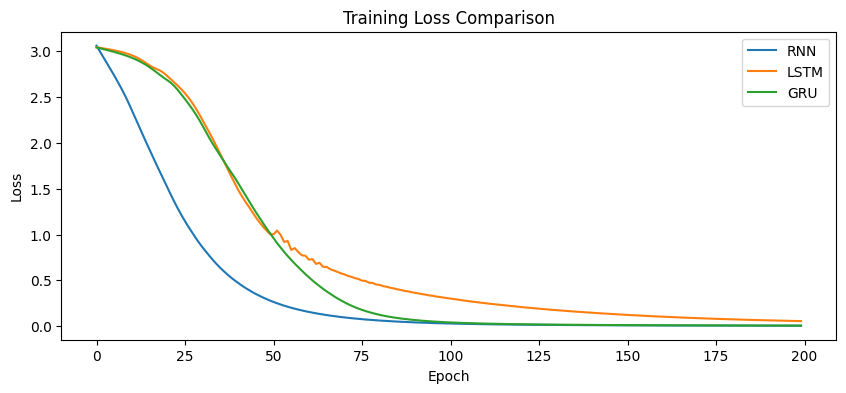

In [83]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

## ✍️ Text Generation Function

This function predicts the next word repeatedly to generate a sentence.

In [84]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [85]:

print("RNN :", generate_text(rnn_model, "to be", 10))
print("LSTM:", generate_text(lstm_model, "to be", 10))
print("GRU :", generate_text(gru_model, "to be", 10))

RNN : to be or not to be that is the question that is
LSTM: to be or not to be that is the question question question
GRU : to be or not to be that is the question question question


## Song lyrics :-

In [86]:
corpus = '''
here comes the sun and i say
its all right little darling
the smiles returning to the faces
'''
print(corpus)


here comes the sun and i say
its all right little darling
the smiles returning to the faces



## Tokenization & Sequence Creation

We convert text into integer tokens and create n-gram style sequences for next-word prediction.

In [87]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 17
X shape: (15, 6)
y shape: (15,)


## 🧠 Model 1: Vanilla RNN
This is the baseline sequential model. It struggles with long-term dependencies because of vanishing gradients.

In [88]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


## 🔒 Model 2: LSTM

LSTM uses input, forget, and output gates to preserve long-term memory.

In [89]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


## ⚡ Model 3: GRU

GRU uses reset + update gates. It is computationally faster than LSTM and often gives similar results.

In [90]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

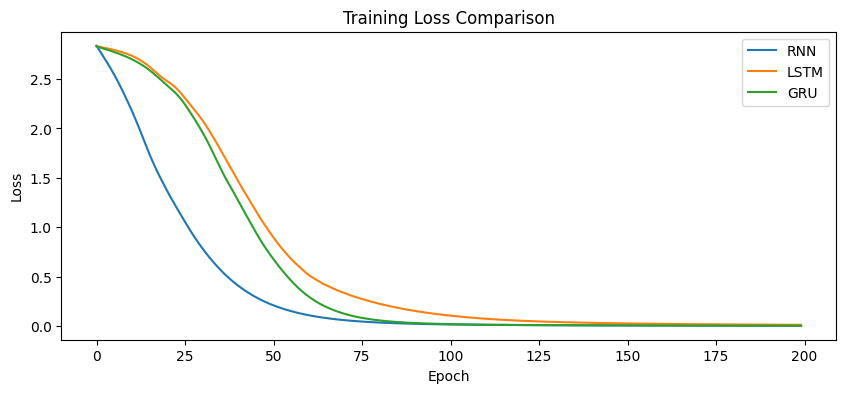

In [91]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

## ✍️ Text Generation Function

This function predicts the next word repeatedly to generate a sentence.

In [92]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [93]:
print("RNN :", generate_text(rnn_model, "here comes", 10))
print("LSTM:", generate_text(lstm_model, "here comes", 10))
print("GRU :", generate_text(gru_model, "here comes", 10))

RNN : here comes the sun and i say faces and i say say
LSTM: here comes the sun and i say say say say say say
GRU : here comes the sun and i say say say say say say


## Chatbot data :-

In [94]:
corpus ='''
hello how are you
i am doing well thank you
what can you help me with
i can answer questions and provide information
'''
print(corpus)


hello how are you
i am doing well thank you
what can you help me with
i can answer questions and provide information



## Tokenization & Sequence Creation

We convert text into integer tokens and create n-gram style sequences for next-word prediction.

In [95]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 20
X shape: (19, 6)
y shape: (19,)


## 🧠 Model 1: Vanilla RNN
This is the baseline sequential model. It struggles with long-term dependencies because of vanishing gradients.

In [96]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


## 🔒 Model 2: LSTM

LSTM uses input, forget, and output gates to preserve long-term memory.

In [97]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


## ⚡ Model 3: GRU

GRU uses reset + update gates. It is computationally faster than LSTM and often gives similar results.

In [98]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

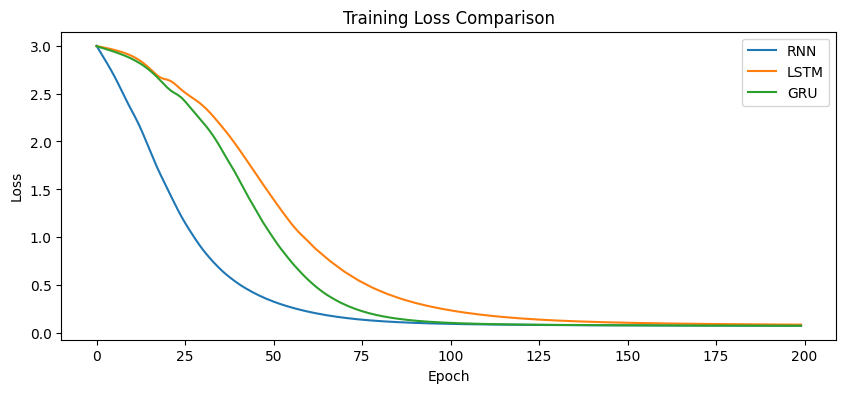

In [99]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

## ✍️ Text Generation Function

This function predicts the next word repeatedly to generate a sentence.

In [100]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [101]:
print("RNN :", generate_text(rnn_model, "hello", 10))
print("LSTM:", generate_text(lstm_model, "hello", 10))
print("GRU :", generate_text(gru_model, "hello", 10))

RNN : hello how are you help me with you you you information
LSTM: hello how are you you you you with with with with
GRU : hello how are you help me with with with with information


## Story paragraph :-

In [102]:
corpus = '''
once upon a time there was a brave knight
the knight lived in a beautiful kingdom
he protected the people from danger
everyone admired his courage and kindness
'''
print(corpus)


once upon a time there was a brave knight
the knight lived in a beautiful kingdom
he protected the people from danger
everyone admired his courage and kindness



## Tokenization & Sequence Creation

We convert text into integer tokens and create n-gram style sequences for next-word prediction.

In [103]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 25
X shape: (24, 8)
y shape: (24,)


## 🧠 Model 1: Vanilla RNN
This is the baseline sequential model. It struggles with long-term dependencies because of vanishing gradients.

In [104]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


## 🔒 Model 2: LSTM

LSTM uses input, forget, and output gates to preserve long-term memory.

In [105]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


## ⚡ Model 3: GRU

GRU uses reset + update gates. It is computationally faster than LSTM and often gives similar results.

In [106]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

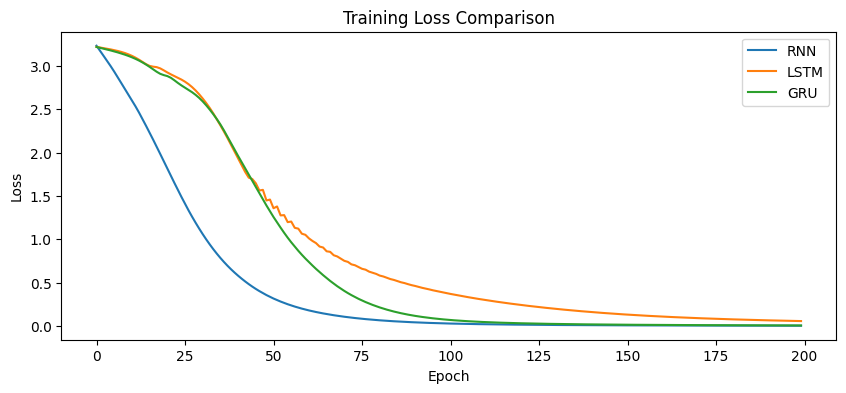

In [107]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

## ✍️ Text Generation Function

This function predicts the next word repeatedly to generate a sentence.

In [108]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [109]:
print("RNN :", generate_text(rnn_model, "once upon", 10))
print("LSTM:", generate_text(lstm_model, "once upon", 10))
print("GRU :", generate_text(gru_model, "once upon", 10))

RNN : once upon a time there was a brave knight lived in a
LSTM: once upon a time there was a brave knight knight knight knight
GRU : once upon a time there was a brave knight knight knight knight


## Custom PDF extracted text


In [110]:
corpus = '''
machine learning is a subset of artificial intelligence
deep learning uses neural networks with multiple layers
data quality plays an important role in model performance
'''
print(corpus)


machine learning is a subset of artificial intelligence
deep learning uses neural networks with multiple layers
data quality plays an important role in model performance



## Tokenization & Sequence Creation

We convert text into integer tokens and create n-gram style sequences for next-word prediction.

In [111]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 25
X shape: (22, 8)
y shape: (22,)


## 🧠 Model 1: Vanilla RNN
This is the baseline sequential model. It struggles with long-term dependencies because of vanishing gradients.

In [112]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


## 🔒 Model 2: LSTM

LSTM uses input, forget, and output gates to preserve long-term memory.

In [113]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


## ⚡ Model 3: GRU

GRU uses reset + update gates. It is computationally faster than LSTM and often gives similar results.

In [114]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

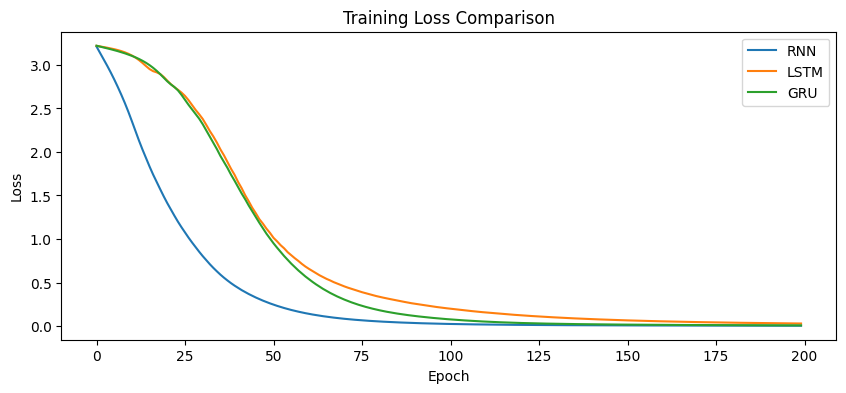

In [115]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

## ✍️ Text Generation Function

This function predicts the next word repeatedly to generate a sentence.

In [116]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [117]:
print("RNN :", generate_text(rnn_model, "machine learning", 10))
print("LSTM:", generate_text(lstm_model, "machine learning", 10))
print("GRU :", generate_text(gru_model, "machine learning", 10))

RNN : machine learning is a subset of artificial intelligence intelligence layers intelligence intelligence
LSTM: machine learning is a subset of artificial intelligence intelligence intelligence intelligence intelligence
GRU : machine learning is a subset of artificial intelligence intelligence intelligence intelligence intelligence


# 📘 Deep Learning Text Generation Learning Project

## Text Generation using Vanilla RNN, LSTM, and GRU

This project demonstrates how Deep Learning sequence models learn language patterns, grammar, contextual relationships, and next-word prediction for text generation.

The notebook is designed for students and beginners to understand the differences between **Vanilla RNN**, **LSTM**, and **GRU** architectures through hands-on experiments.

---

## 🎯 Project Objective

Design and implement Deep Learning models capable of learning the structure, grammar, and contextual dependencies of text to generate meaningful sequences.

Models Implemented:

* Vanilla RNN
* LSTM (Long Short-Term Memory)
* GRU (Gated Recurrent Unit)

The project compares:

* Training Loss
* Generated Text Quality
* Memory Handling
* Long-Term Dependency Learning
* Computational Efficiency

---

## 🧠 Learning Outcomes

By completing this project, students will learn:

* Text preprocessing and tokenization
* Sequence generation for next-word prediction
* Word embeddings
* Recurrent Neural Networks
* LSTM architecture and gating mechanisms
* GRU architecture and memory optimization
* Text generation using trained sequence models
* Comparison of sequence modeling architectures

---

## 📂 Project Workflow

```text
Text Corpus
     ↓
Tokenization
     ↓
Sequence Generation
     ↓
Padding
     ↓
Input Features (X)
Target Labels (y)
     ↓
Embedding Layer
     ↓
RNN / LSTM / GRU
     ↓
Softmax Output
     ↓
Next Word Prediction
     ↓
Text Generation
```

---

## ⚙️ Technologies Used

* Python
* TensorFlow / Keras
* NumPy
* Matplotlib

---

## 📥 Datasets Used

A small built-in corpus is used for quick experimentation.

Students can replace it with:

* Shakespeare Text
* Song Lyrics
* Chatbot Conversations
* Story Paragraphs
* Custom PDF Extracted Text
* Research Articles
* News Articles

---

## 🔤 Text Preprocessing

The project performs:

### Tokenization

Converts words into integer tokens.

Example:

```python
deep learning is transforming artificial intelligence
```

↓

```text
[1, 2, 3, 4, 5]
```

### Sequence Generation

Creates n-gram sequences:

```text
deep learning
deep learning is
deep learning is transforming
```

### Padding

Ensures all sequences have equal length before training.

---

## 🧠 Model Architectures

### 1. Vanilla RNN

```python
Embedding
↓
SimpleRNN(128)
↓
Dense(Softmax)
```

#### Advantages

* Simple architecture
* Fast training
* Easy to understand

#### Limitations

* Suffers from vanishing gradients
* Poor long-term memory

---

### 2. LSTM

```python
Embedding
↓
LSTM(128)
↓
Dense(Softmax)
```

#### Features

* Input Gate
* Forget Gate
* Output Gate

#### Advantages

* Handles long-term dependencies
* Better contextual understanding
* Improved text generation quality

---

### 3. GRU

```python
Embedding
↓
GRU(128)
↓
Dense(Softmax)
```

#### Features

* Update Gate
* Reset Gate

#### Advantages

* Faster than LSTM
* Fewer parameters
* Similar performance to LSTM

---

## 📊 Model Comparison

| Feature                | RNN   | LSTM      | GRU       |
| ---------------------- | ----- | --------- | --------- |
| Memory Handling        | Poor  | Excellent | Very Good |
| Long-Term Dependencies | Weak  | Strong    | Strong    |
| Training Speed         | Fast  | Slowest   | Faster    |
| Complexity             | Low   | High      | Medium    |
| Text Quality           | Basic | Best      | Near LSTM |

---

## 🧪 Experiments Performed

### Experiment 1: AI Corpus

```text
machine learning is a subset of artificial intelligence
deep learning uses neural networks with multiple layers
data quality plays an important role in model performance
```

Sample Output:

```text
RNN  : machine learning is a subset of artificial intelligence ...
LSTM : machine learning is a subset of artificial intelligence ...
GRU  : machine learning is a subset of artificial intelligence ...
```

---

### Experiment 2: Shakespeare Corpus

```text
to be or not to be that is the question
whether tis nobler in the mind to suffer
the slings and arrows of outrageous fortune
```

Sample Output:

```text
RNN  : to be or not to be that is the question ...
LSTM : to be or not to be that is the question ...
GRU  : to be or not to be that is the question ...
```

---

### Experiment 3: Song Lyrics

```text
here comes the sun and i say
its all right little darling
the smiles returning to the faces
```

---

### Experiment 4: Chatbot Conversations

```text
hello how are you
i am doing well thank you
what can you help me with
i can answer questions and provide information
```

---

### Experiment 5: Story Generation

```text
once upon a time there was a brave knight
the knight lived in a beautiful kingdom
he protected the people from danger
everyone admired his courage and kindness
```

---

## 📉 Training Loss Analysis

Training loss curves are plotted for:

* RNN
* LSTM
* GRU

The graphs help visualize:

* Convergence speed
* Learning stability
* Model performance differences

---

## ✍️ Text Generation

After training, each model predicts the next word repeatedly to generate text.

Example:

```python
generate_text(model, "machine learning", 10)
```

Output:

```text
machine learning is a subset of artificial intelligence ...
```

---

## 🎓 Student Tasks

### Beginner

* Replace corpus with your own text
* Increase epochs from 100 → 200
* Increase embedding dimension
* Change hidden units from 64 → 128
* Generate longer text sequences

### Intermediate

* Add Dropout
* Add Bidirectional LSTM
* Use larger datasets
* Experiment with temperature sampling

### Advanced

* Attention Mechanisms
* Transformer Models
* GPT-style Text Generation
* Character-Level Text Generation

---

## 🚀 Future Improvements

* Beam Search Decoding
* Transformer Architecture
* GPT Implementation
* Pretrained Word Embeddings
* Large Corpus Training
* PDF Text Extraction Pipeline
* Interactive Web Interface

---

## 🏆 Conclusion

This project demonstrates the fundamentals of sequence modeling and text generation using Deep Learning.

Key Findings:

* Vanilla RNN learns basic language patterns but struggles with long-term memory.
* LSTM produces the most coherent and context-aware text.
* GRU achieves performance close to LSTM while training faster.
* Dataset quality and size significantly influence generated text quality.

This project serves as an excellent foundation for understanding modern NLP systems, language models, and generative AI architectures.
